Notebook for the following analyses (4.1-4.4):
- Descriptive statistics of LLM data
- Comparison between LLM data and human aggregate
- Analysis of change in agreement when replacing a human annotator with an LLM
- Alt-test

Note:
- All LLM annotations and the original human data are already turned into long format tables in preprocessing.
- The effect of rating scale granularity on LLM annotations is explored in another notebook.

In [16]:
import pandas as pd

Read the data:

In [17]:
df_llm = pd.read_csv('llm_scores.csv')
df_human = pd.read_csv('human_scores.csv')

In [18]:
print(df_llm.head())
print(df_human.head())

                 tweet_id  dimension method model  score
0  ['901760751152623616']    valence     rs   gpt   0.65
1  ['901760751152623616']    arousal     rs   gpt   0.58
2  ['901760751152623616']  dominance     rs   gpt   0.52
3  ['863364746577313792']    valence     rs   gpt   0.91
4  ['863364746577313792']    arousal     rs   gpt   0.87
                 tweet_id dimension method annotator  score
0  ['872197389276385280']   valence     rs        A9   0.73
1  ['906447947092647936']   valence     rs        A9   0.25
2  ['929386800522645508']   valence     rs        A9   0.78
3  ['839145863217889282']   valence     rs        A9   0.00
4  ['867703984580169730']   valence     rs        A9   0.35


In [19]:
# Number of tweet-level ratings:

print(len(df_llm)) # 100 tweets * 3 dimensions * 3 methods * 3 models = 2700 rows
print(len(df_human)) # 100 tweets * 3 dimensions * 3 methods * 6 annotators = 5400 rows

2700
5400


Part 1. Descriptive statistics of LLM data

In [20]:
# Calculate mean, std and skew for each model-method-dimension combination:

from scipy.stats import skew

llm_stats = df_llm.groupby(['model', 'method', 'dimension']).agg(
    mean=('score', 'mean'),
    std=('score', 'std'),
    skew=('score', lambda x: skew(x, bias=False))
).reset_index()

llm_stats.round(3)

,model,method,dimension,mean,std,skew
0,gpt,bws,arousal,0.516,0.230,0.087
1,gpt,bws,dominance,0.505,0.227,-0.039
2,gpt,bws,valence,0.512,0.235,0.010
3,gpt,pc,arousal,0.538,0.250,-0.030
4,gpt,pc,dominance,0.541,0.249,0.004
5,gpt,pc,valence,0.535,0.249,0.019
6,gpt,rs,arousal,0.617,0.123,-0.105
7,gpt,rs,dominance,0.547,0.126,-0.589
8,gpt,rs,valence,0.590,0.229,-0.667
9,mini,bws,arousal,0.514,0.223,0.075


In [ ]:
# Calculate mean, std and skew for each method-dimension combination in aggregated human data (Batch 1), to compare with LLM stats:

# First aggregate human ratings (mean) at tweet level:

human_agg = df_human.groupby(["tweet_id", "method", "dimension"], as_index=False).agg(
        human_mean=("score", "mean"),
        human_sd=("score", "std") # SD of the human ratings for each tweet reflects original data dispersion & human (dis)agreement per tweet, but this data is not ultimately used.
)

print(len(human_agg)) # 5400 / 6 = 900.

# Then compute mean, std and skew:

human_stats = human_agg.groupby(['method', 'dimension']).agg(
        mean=('human_mean', 'mean'),
        std=('human_mean', 'std'),
        skew=('human_mean', lambda x: skew(x, bias=False))
).reset_index()

human_stats.round(3)


900


,method,dimension,mean,std,skew
0,bws,arousal,0.509,0.131,0.114
1,bws,dominance,0.507,0.130,-0.423
2,bws,valence,0.510,0.197,-0.015
3,pc,arousal,0.540,0.139,0.141
4,pc,dominance,0.533,0.118,-0.279
5,pc,valence,0.544,0.194,0.123
6,rs,arousal,0.626,0.099,0.102
7,rs,dominance,0.592,0.096,-0.376
8,rs,valence,0.563,0.195,-0.484


Part 2. LLM-human alignment

In [22]:
import numpy as np
from scipy.stats import pearsonr

In [24]:
# calculate pearson's r for each model-method-dimension

results = []

# select the combination
for model in df_llm["model"].unique():
    for method in df_llm["method"].unique():
        for dimension in df_llm["dimension"].unique():

            # LLM data for this combination
            llm_scores = df_llm[
                (df_llm["model"] == model) &
                (df_llm["method"] == method) &
                (df_llm["dimension"] == dimension)
            ].sort_values("tweet_id")["score"].to_numpy()

            # Human data for this combination
            human_scores = human_agg[
                (human_agg["method"] == method) &
                (human_agg["dimension"] == dimension)
            ].sort_values("tweet_id")["human_mean"].to_numpy()

            # calculate
            r, p = pearsonr(llm_scores, human_scores)
            
            results.append({
                "model": model,
                "method": method,
                "dimension": dimension,
                "pearson_r": r,
                "p_value": p
            })

pearsonr_df = pd.DataFrame(results)
pearsonr_df.round(3)

,model,method,dimension,pearson_r,p_value
0,gpt,rs,valence,0.847,0.0
1,gpt,rs,arousal,0.612,0.0
2,gpt,rs,dominance,0.671,0.0
3,gpt,pc,valence,0.653,0.0
4,gpt,pc,arousal,0.493,0.0
5,gpt,pc,dominance,0.467,0.0
6,gpt,bws,valence,0.813,0.0
7,gpt,bws,arousal,0.706,0.0
8,gpt,bws,dominance,0.700,0.0
9,mini,rs,valence,0.875,0.0


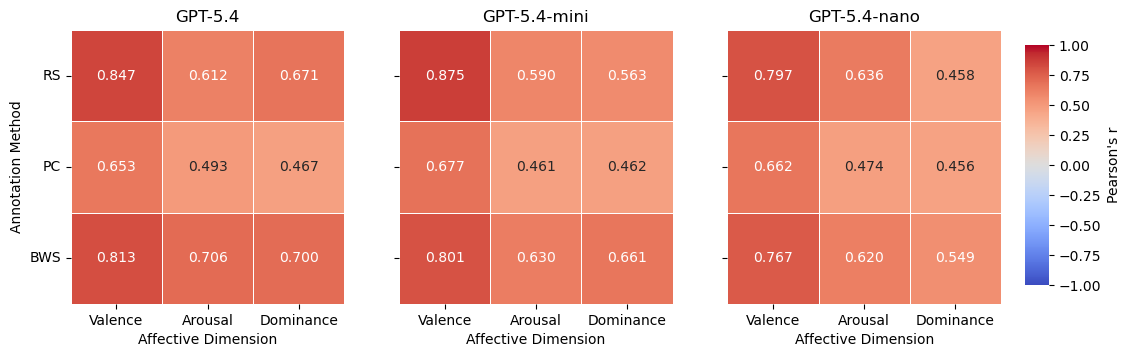

In [14]:
# visualize by correlation heatmaps (for each model)
# 3 squares spread horizontally, sharing one y axis label and one colorbar.

import matplotlib.pyplot as plt
import seaborn as sns

method_order = ["rs", "pc", "bws"]
dimension_order = ["valence", "arousal", "dominance"]

method_labels = ["RS", "PC", "BWS"]
dimension_labels = ["Valence", "Arousal", "Dominance"]

pearsonr_df["model_label"] = pearsonr_df["model"].map({
    "gpt": "GPT-5.4",
    "mini": "GPT-5.4-mini",
    "nano": "GPT-5.4-nano"
})
models = pearsonr_df["model_label"].unique()

fig, axes = plt.subplots(
    1, 
    len(models), 
    figsize=(4 * len(models), 4),
    sharex=True,
    sharey=True
)

cbar_ax = fig.add_axes([0.92, 0.20, 0.02, 0.60])

for i, (ax, model) in enumerate(zip(axes, models)):

    model_corr = pearsonr_df[pearsonr_df["model_label"] == model]

    heatmap_data = model_corr.pivot(
        index="method",
        columns="dimension",
        values="pearson_r"
    )
    
    heatmap_data = heatmap_data.reindex(
        index=method_order,
        columns=dimension_order
    )
    
    sns.heatmap(
        heatmap_data,
        ax=ax,
        annot=True,
        fmt=".3f",
        vmin=-1,
        vmax=1,
        center=0,
        cmap="coolwarm",
        linewidths=0.5,
        square=True,
        cbar=(i == len(models) - 1),
        cbar_ax=cbar_ax if i == len(models) - 1 else None,
        cbar_kws={"label": "Pearson's r"}
    )

    ax.set_title(model)
    
    ax.set_xlabel("Affective Dimension")
    ax.set_ylabel("Annotation Method" if i == 0 else "")
    
    ax.set_xticklabels(dimension_labels, rotation=0)
    ax.set_yticklabels(method_labels, rotation=0)

plt.show()

Part 3. Replacement analysis based on agreement changes

In [ ]:
import krippendorff

In [29]:
# dataframes used (long format)
print(df_llm.head())
print(df_human.head())

                 tweet_id  dimension method model  score
0  ['901760751152623616']    valence     rs   gpt   0.65
1  ['901760751152623616']    arousal     rs   gpt   0.58
2  ['901760751152623616']  dominance     rs   gpt   0.52
3  ['863364746577313792']    valence     rs   gpt   0.91
4  ['863364746577313792']    arousal     rs   gpt   0.87
                 tweet_id dimension method annotator  score
0  ['872197389276385280']   valence     rs        A9   0.73
1  ['906447947092647936']   valence     rs        A9   0.25
2  ['929386800522645508']   valence     rs        A9   0.78
3  ['839145863217889282']   valence     rs        A9   0.00
4  ['867703984580169730']   valence     rs        A9   0.35


In [30]:
# function for calculating Krippendorff's alpha for a given model, method, dimension

def get_alpha(df, raters):

    matrix = (
        df.pivot(index=raters, columns="tweet_id", values="score")
          .sort_index()
    )

    return krippendorff.alpha(
        reliability_data=matrix.to_numpy(),
        level_of_measurement="interval"
    )

In [ ]:
# first compute original alpha in human data; the original paper also reports this, check if it's the same.

methods = ["rs", "pc", "bws"]
dimensions = ["valence", "arousal", "dominance"]

results = []

for method in methods:
    for dimension in dimensions:

        subset = df_human[
            (df_human["method"] == method) &
            (df_human["dimension"] == dimension)
        ]

        alpha = get_alpha(subset, raters="annotator")

        results.append({
            "method": method,
            "dimension": dimension,
            "original_alpha": alpha
        })

df_human_alpha = pd.DataFrame(results)

df_human_alpha.round(3) # output values are the same as the original paper reported! (Table 6, p.1031: Batch 1).

,method,dimension,original_alpha
0,rs,valence,0.582
1,rs,arousal,0.242
2,rs,dominance,0.112
3,pc,valence,0.563
4,pc,arousal,0.244
5,pc,dominance,0.127
6,bws,valence,0.708
7,bws,arousal,0.328
8,bws,dominance,0.308


In [ ]:
# calculate replacement alpha:

models = ["gpt", "mini", "nano"]

replacement_results = []

for model in models:
    for method in methods:
        for dimension in dimensions:

            human_subset = df_human[
                (df_human["method"] == method) &
                (df_human["dimension"] == dimension)
            ]

            llm_subset = df_llm[
                (df_llm["model"] == model) &
                (df_llm["method"] == method) &
                (df_llm["dimension"] == dimension)
            ]

            original_alpha = df_human_alpha.loc[
                (df_human_alpha["method"] == method) &
                (df_human_alpha["dimension"] == dimension),
                "original_alpha"
            ].iloc[0]

            annotators = human_subset["annotator"].unique()

            for annotator in annotators:

                remaining_data = human_subset[human_subset["annotator"] != annotator]
                llm_data = llm_subset.copy()
                llm_data["annotator"] = model

                replacement_data = pd.concat([remaining_data, llm_data], ignore_index=True)
                replacement_alpha = get_alpha(replacement_data, raters="annotator")

                delta_alpha = replacement_alpha - original_alpha

                replacement_results.append({
                    "model": model,
                    "method": method,
                    "dimension": dimension,
                    "replaced_annotator": annotator,
                    "original_alpha": original_alpha,
                    "replacement_alpha": replacement_alpha,
                    "delta_alpha": delta_alpha
                })

replacement_df = pd.DataFrame(replacement_results)
replacement_df # 3 models * 3 methods * 3 dimensions * 6 (replaced) annotators = 162 rows

,model,method,dimension,replaced_annotator,original_alpha,replacement_alpha,delta_alpha
0,gpt,rs,valence,A9,0.581980,0.607208,0.025228
1,gpt,rs,valence,A1,0.581980,0.601050,0.019070
2,gpt,rs,valence,A4,0.581980,0.612491,0.030511
3,gpt,rs,valence,A11,0.581980,0.613426,0.031445
4,gpt,rs,valence,A14,0.581980,0.639247,0.057267
...,...,...,...,...,...,...,...
157,nano,bws,dominance,A10,0.307902,0.352173,0.044271
158,nano,bws,dominance,A3,0.307902,0.310710,0.002809
159,nano,bws,dominance,A15,0.307902,0.274349,-0.033553
160,nano,bws,dominance,A5,0.307902,0.378984,0.071082


In [ ]:
# calculate agreement change to report in the paper:
# original alpha: human agreement;
# mean replacement alpha: average of 6 replacement alphas (agreement when 1 annotator is replaced);
# mean delta alpha: average of 6 delta alphas (agreement change);
# min/max delta alpha: the range of agreement change when different annotators are replaced.


agreement_change_df = (
    replacement_df
    .groupby(["model", "method", "dimension"], as_index=False)
    .agg(
        original_alpha=("original_alpha", "first"),
        mean_replacement_alpha=("replacement_alpha", "mean"),
        mean_delta_alpha=("delta_alpha", "mean"),
        min_delta_alpha=("delta_alpha", "min"),
        max_delta_alpha=("delta_alpha", "max")
    )
)

agreement_change_df.round(3)

,model,method,dimension,original_alpha,mean_replacement_alpha,mean_delta_alpha,min_delta_alpha,max_delta_alpha
0,gpt,bws,arousal,0.328,0.376,0.048,-0.015,0.244
1,gpt,bws,dominance,0.308,0.360,0.052,0.002,0.109
2,gpt,bws,valence,0.708,0.708,-0.000,-0.023,0.025
3,gpt,pc,arousal,0.244,0.263,0.019,-0.021,0.037
4,gpt,pc,dominance,0.127,0.168,0.041,-0.020,0.075
5,gpt,pc,valence,0.563,0.548,-0.014,-0.035,0.034
6,gpt,rs,arousal,0.242,0.272,0.030,0.016,0.061
7,gpt,rs,dominance,0.112,0.161,0.050,0.023,0.124
8,gpt,rs,valence,0.582,0.613,0.031,0.019,0.057
9,mini,bws,arousal,0.328,0.358,0.029,-0.034,0.225


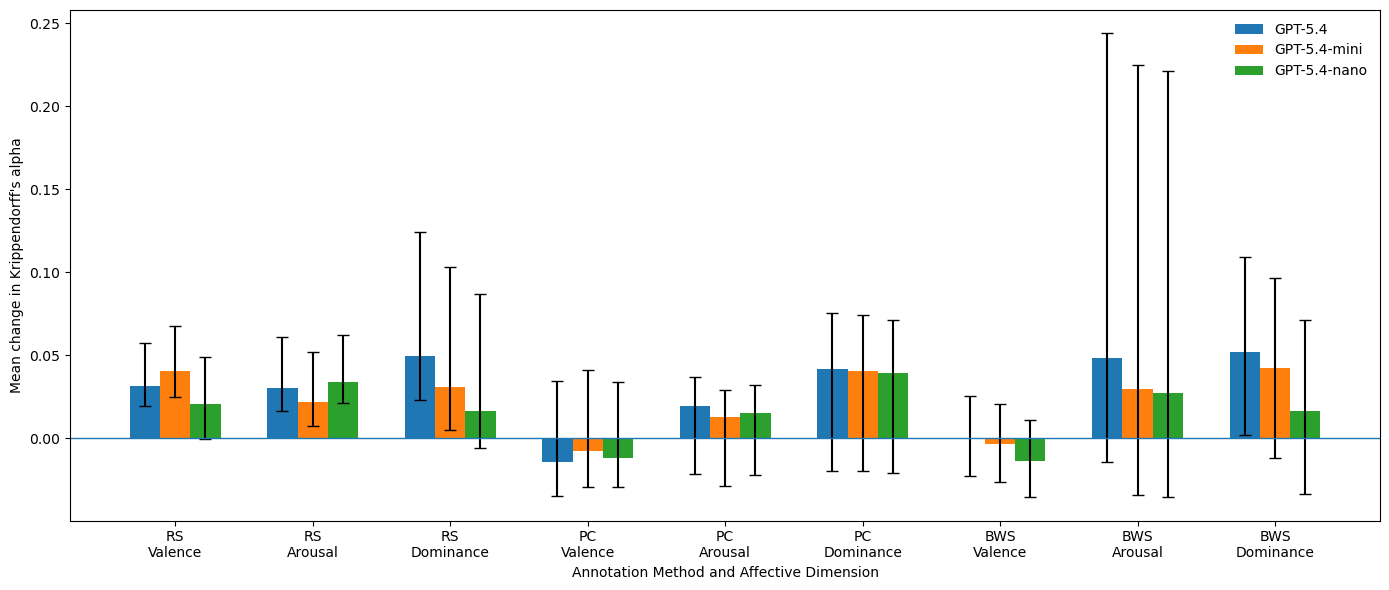

In [ ]:
# Visualization: plot the change of agreement (delta alpha), bar plot
# delta alpha: bars;
# min/max: error bars

df = agreement_change_df.copy()

# Display names:
model_name_map = {
    "gpt": "GPT-5.4",
    "mini": "GPT-5.4-mini",
    "nano": "GPT-5.4-nano"
}

method_name_map = {
    "rs": "RS",
    "pc": "PC",
    "bws": "BWS"
}

dimension_name_map = {
    "valence": "Valence",
    "arousal": "Arousal",
    "dominance": "Dominance"
}

df["model"] = df["model"].replace(model_name_map)
df["method"] = df["method"].replace(method_name_map)
df["dimension"] = df["dimension"].replace(dimension_name_map)

method_order = ["RS", "PC", "BWS"]
dimension_order = ["Valence", "Arousal", "Dominance"]
x_order = [(m, d) for m in method_order for d in dimension_order]

df["method"] = pd.Categorical(df["method"], categories=method_order, ordered=True)
df["dimension"] = pd.Categorical(df["dimension"], categories=dimension_order, ordered=True)
df = df.sort_values(["method", "dimension", "model"])

# Error bars
df["yerr_lower"] = df["mean_delta_alpha"] - df["min_delta_alpha"]
df["yerr_upper"] = df["max_delta_alpha"] - df["mean_delta_alpha"]

models = ["GPT-5.4", "GPT-5.4-mini", "GPT-5.4-nano"]
x_labels = [f"{m}\n{d}" for m, d in x_order]

x = np.arange(len(x_order))
bar_width = 0.22
offsets = [-bar_width, 0, bar_width]

fig, ax = plt.subplots(figsize=(14, 6))

for i, model in enumerate(models):
    sub = df[df["model"] == model].copy()
    sub = sub.set_index(["method", "dimension"]).loc[x_order].reset_index()

    y = sub["mean_delta_alpha"].to_numpy()
    yerr = np.vstack([
        sub["yerr_lower"].to_numpy(),
        sub["yerr_upper"].to_numpy()
    ])

    xpos = x + offsets[i]

    ax.bar(
        xpos,
        y,
        width=bar_width,
        label=model,
        yerr=yerr,
        capsize=4
    )

ax.axhline(0, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_xlabel("Annotation Method and Affective Dimension")
ax.set_ylabel("Mean change in Krippendorff's alpha")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Part 4. Alt-test
- The code (functions) here is taken from Calderon et al.'s AltTest notebook, openly available on GitHub (https://github.com/nitaytech/AltTest), and adapted for the present data.

Reference:

Calderon, Nitay, Roi Reichart, and Rotem Dror. 2025. The alternative annotator test for LLM-as-a-judge: How to statistically justify replacing human annotators with LLMs. In Proceedings of the 63rd Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers), pages 16051–16081, Association for Computational Linguistics, Vienna, Austria.


In [8]:
from scipy.stats import ttest_1samp
from typing import Any, List, Dict, Union, Callable

In [12]:
def by_procedure(p_values: List[float], q: float) -> List[int]: # Benjamini-Yekutieli procedure for multiple comparisons correction
    p_values = np.array(p_values, dtype=float)
    m = len(p_values)
    sorted_indices = np.argsort(p_values)
    sorted_pvals = p_values[sorted_indices]

    H_m = np.sum(1.0 / np.arange(1, m + 1))
    by_thresholds = (np.arange(1, m + 1) / m) * (q / H_m)

    max_i = -1
    for i in range(m):
        if sorted_pvals[i] <= by_thresholds[i]:
            max_i = i

    if max_i == -1:
        return []

    rejected_sorted_indices = sorted_indices[:max_i + 1]
    return list(rejected_sorted_indices)

def neg_rmse(pred: Union[int, float], annotations: List[Union[int, float]]) -> float:
    return -1 * float(np.sqrt(np.mean([(pred - ann) ** 2 for ann in annotations])))


def ttest(indicators, epsilon: float) -> float:
    return ttest_1samp(indicators, epsilon, alternative="less").pvalue


def alt_test(
    llm_annotations: Dict[Union[int, str], Any],
    humans_annotations: Dict[Union[int, str], Dict[Union[int, str], Any]],
    scoring_function: Union[str, Callable],
    epsilon: float = 0.15,
    q_fdr: float = 0.05,
    min_humans_per_instance: int = 2,
    min_instances_per_human: int = 30
):
    # prepare alignment scoring function
    if isinstance(scoring_function, str):
        if scoring_function == 'neg_rmse':
            scoring_function = neg_rmse
        else:
            raise ValueError("Unknown scoring function")
    else:
        scoring_function = scoring_function

    # prepare sets - i_set has humans as keys, h_set has instances as keys
    i_set, h_set = {}, {}

    for h, anns in humans_annotations.items():
        i_set[h] = list(anns.keys())
        for i, ann in anns.items():
            if i not in h_set:
                h_set[i] = []
            h_set[i].append(h)

    # remove instances with less than min_humans_per_instance
    instances_to_keep = {i for i in h_set if len(h_set[i]) >= min_humans_per_instance and i in llm_annotations}
    i_set = {h: [i for i in i_set[h] if i in instances_to_keep] for h in i_set}
    h_set = {i: h_set[i] for i in h_set if i in instances_to_keep}

    p_values, advantage_probs, humans = [], [], []
    for excluded_h in humans_annotations:
        llm_indicators = []
        excluded_indicators = []
        instances = [i for i in i_set[excluded_h] if i in llm_annotations]
        if len(instances) < min_instances_per_human:
            continue

        for i in instances:
            human_ann = humans_annotations[excluded_h][i]
            llm_ann = llm_annotations[i]
            remaining_anns = [humans_annotations[h][i] for h in h_set[i] if h != excluded_h]
            human_score = scoring_function(human_ann, remaining_anns)
            llm_score = scoring_function(llm_ann, remaining_anns)
            llm_indicators.append(1 if llm_score >= human_score else 0)
            excluded_indicators.append(1 if human_score >= llm_score else 0)

        diff_indicators = [exc_ind - llm_ind for exc_ind, llm_ind in zip(excluded_indicators, llm_indicators)]
        p_values.append(ttest(diff_indicators, epsilon))
        advantage_probs.append(float(np.mean(llm_indicators)))
        humans.append(excluded_h)

    rejected_indices = by_procedure(p_values, q_fdr)
    advantage_prob = float(np.mean(advantage_probs))
    winning_rate = len(rejected_indices) / len(humans)

    return winning_rate, advantage_prob

In [13]:
# turn my dataframes into dictionary format for input to the alt-test function:

def prepare_alt_test_inputs(df_human, df_llm, model, method, dimension):
    
    # Human annotations: {annotator_id: {tweet_id: score}}
    human_subset = df_human[
        (df_human["method"] == method) &
        (df_human["dimension"] == dimension)
    ]

    humans_annotations = {
        annotator: group.set_index("tweet_id")["score"].to_dict()
        for annotator, group in human_subset.groupby("annotator")
    }

    # LLM annotations: {tweet_id: score}
    llm_subset = df_llm[
        (df_llm["model"] == model) &
        (df_llm["method"] == method) &
        (df_llm["dimension"] == dimension)
    ]

    llm_annotations = llm_subset.set_index("tweet_id")["score"].to_dict()

    return llm_annotations, humans_annotations

In [14]:
results = []

for model in sorted(df_llm["model"].unique()):
    for method in sorted(df_llm["method"].unique()):
        for dimension in sorted(df_llm["dimension"].unique()):

            llm_annotations, humans_annotations = prepare_alt_test_inputs(
                df_human=df_human,
                df_llm=df_llm,
                model=model,
                method=method,
                dimension=dimension
            )

            winning_rate, advantage_prob = alt_test(
                llm_annotations=llm_annotations,
                humans_annotations=humans_annotations,
                scoring_function="neg_rmse",
                epsilon=0.15,
                q_fdr=0.05,
                min_humans_per_instance=2,
                min_instances_per_human=30
            )

            results.append({
                "model": model,
                "method": method,
                "dimension": dimension,
                "winning_rate": winning_rate,
                "advantage_prob": advantage_prob,
                "passed": winning_rate >= 0.5
            })

alt_results_df = pd.DataFrame(results)
alt_results_df["advantage_prob"] = alt_results_df["advantage_prob"].round(3)
alt_results_df["winning_rate"] = alt_results_df["winning_rate"].round(3)

alt_results_df

,model,method,dimension,winning_rate,advantage_prob,passed
0,gpt,bws,arousal,0.167,0.493,False
1,gpt,bws,dominance,0.333,0.522,False
2,gpt,bws,valence,0.000,0.453,False
3,gpt,pc,arousal,0.000,0.495,False
4,gpt,pc,dominance,0.167,0.517,False
5,gpt,pc,valence,0.000,0.445,False
6,gpt,rs,arousal,1.000,0.625,True
7,gpt,rs,dominance,1.000,0.727,True
8,gpt,rs,valence,1.000,0.662,True
9,mini,bws,arousal,0.167,0.480,False
